## Architecture #3 + Sparse Categorical Cross Entropy

##### 1. Imports

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.layers import ( 
    SpatialDropout1D, Embedding, Bidirectional, 
    LSTM, Dense, Dropout, 
    BatchNormalization, Input, Layer,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate,
    Attention, MultiHeadAttention, LayerNormalization
)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

2026-01-31 08:41:48.234310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769848908.426620      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769848908.481779      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.keras.utils.set_random_seed(42)

##### 2. Load Dataset

In [3]:
file = r"/kaggle/input/bias-detection-dataset-processed/balanced_bias_data_parquet.parquet"
balanced_df = pd.read_parquet(file)

print(balanced_df)
print("\nColumns:", balanced_df.columns)
print("\nShape:", balanced_df.shape)

         Unnamed: 0                                               text  \
0                 0  im okay with it being there and im not religious.   
1                 1  nn chchchchina nnlets dialogue about this wond...   
2                 2  ianbetteridge firefox2, no idea what version o...   
3                 3  so kool!i didnt know he came to alaska.i was 1...   
4                 4  catwoman123 if you know the real demi moore an...   
...             ...                                                ...   
2856798     2856798  i see that someone answered on your talk page....   
2856799     2856799  sheriff joe as you affectionately call him had...   
2856800     2856800  your incredulity doesnt make your claim any mo...   
2856801     2856801  find someone elses comment to spew your islamo...   
2856802     2856802  your link is an interesting read and very bala...   

                                         biased_words  bias  sentiment  toxic  \
0                             

##### 3. Tokenisation & Padding

In [4]:
MAX_VOCAB = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(balanced_df['text'])

X = tokenizer.texts_to_sequences(balanced_df['text'])
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
print(X.shape)

(2856803, 100)


##### 4. Train-Test Split

In [5]:
y = balanced_df[['bias', 'sentiment', 'toxic']]
print(y)
print(y.shape)

         bias  sentiment  toxic
0           1          2      0
1           1          2      0
2           1          2      0
3           1          2      0
4           1          2      0
...       ...        ...    ...
2856798     0          1      0
2856799     0          1      0
2856800     0          1      0
2856801     0          1      0
2856802     0          1      0

[2856803 rows x 3 columns]
(2856803, 3)


In [6]:
# split for training, testing and validation as 80%-10%-10%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [7]:
# convert to numpy.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_valid:", X_valid.shape)

y_train_bias = y_train["bias"].to_numpy()
y_train_sentiment = y_train["sentiment"].to_numpy()
y_train_toxic = y_train["toxic"].to_numpy()

print("y_train_bias:", y_train_bias.shape)
print("y_train_sentiment:", y_train_sentiment.shape)
print("y_train_toxic:", y_train_toxic.shape)

y_test_bias = y_test["bias"].to_numpy()
y_test_sentiment = y_test["sentiment"].to_numpy()
y_test_toxic = y_test["toxic"].to_numpy()

print("y_test_bias:", y_test_bias.shape)
print("y_test_sentiment:", y_test_sentiment.shape)
print("y_test_toxic:", y_test_toxic.shape)

y_valid_bias = y_valid["bias"].to_numpy()
y_valid_sentiment = y_valid["sentiment"].to_numpy()
y_valid_toxic = y_valid["toxic"].to_numpy()

print("y_valid_bias:", y_valid_bias.shape)
print("y_valid_sentiment:", y_valid_sentiment.shape)
print("y_valid_toxic:", y_valid_toxic.shape)

X_train: (1999762, 100)
X_test: (428520, 100)
X_valid: (428521, 100)
y_train_bias: (1999762,)
y_train_sentiment: (1999762,)
y_train_toxic: (1999762,)
y_test_bias: (428520,)
y_test_sentiment: (428520,)
y_test_toxic: (428520,)
y_valid_bias: (428521,)
y_valid_sentiment: (428521,)
y_valid_toxic: (428521,)


##### 5. Model Architecture

In [8]:
def build_model():
    MAX_VOCAB = 10000
    input_layer = Input(shape=(100,))
    
    x = Embedding(MAX_VOCAB, 512, trainable=True)(input_layer)
    
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    # Multi-head attention
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    
    # Dual pooling
    avg_pool = GlobalAveragePooling1D()(attn)
    max_pool = GlobalMaxPooling1D()(attn)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(256, activation="gelu")(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation="gelu", kernel_regularizer=l2(1e-4))(x)

    neutro = Dense(128, activation="tanh", name="neutro_latent")(x)
    
    # Output heads
    output_b = Dense(3, activation='linear', name='output_b')(neutro)
    output_s = Dense(3, activation='linear', name='output_s')(neutro)
    output_t = Dense(2, activation='linear', name='output_t')(neutro)
    
    model = Model(inputs=input_layer, outputs=[output_b, output_s, output_t])

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=10000,
        decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss={
            "output_b": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            "output_s": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            "output_t": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        },
        metrics={
            "output_b": "sparse_categorical_accuracy",
            "output_s": "sparse_categorical_accuracy",
            "output_t": "sparse_categorical_accuracy"
        }
    )
    return model

##### 6. Model Training

In [9]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model = build_model()

history = model.fit(
    X_train,
    {
        "output_b": y_train_bias,
        "output_s": y_train_sentiment,
        "output_t": y_train_toxic
    },
    validation_data=(
        X_valid,
        {
            "output_b": y_valid_bias,
            "output_s": y_valid_sentiment,
            "output_t": y_valid_toxic
        }
    ),
    epochs=10,
    batch_size=512,
    verbose=1,
    callbacks=[early_stopping]
)

I0000 00:00:1769849068.759980      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1769849083.277402      69 cuda_dnn.cc:529] Loaded cuDNN version 90300


3906/3906 ━━━━━━━━━━━━━━━━━━━━ 649s 163ms/step - loss: 1.3931 - output_b_loss: 0.4886 - output_b_sparse_categorical_accuracy: 0.7951 - output_s_loss: 0.4623 - output_s_sparse_categorical_accuracy: 0.8204 - output_t_loss: 0.4299 - output_t_sparse_categorical_accuracy: 0.7871 - val_loss: 0.9670 - val_output_b_loss: 0.3503 - val_output_b_sparse_categorical_accuracy: 0.8637 - val_output_s_loss: 0.2669 - val_output_s_sparse_categorical_accuracy: 0.9125 - val_output_t_loss: 0.3445 - val_output_t_sparse_categorical_accuracy: 0.8424
Epoch 2/10
3906/3906 ━━━━━━━━━━━━━━━━━━━━ 636s 163ms/step - loss: 0.9481 - output_b_loss: 0.3458 - output_b_sparse_categorical_accuracy: 0.8664 - output_s_loss: 0.2647 - output_s_sparse_categorical_accuracy: 0.9142 - output_t_loss: 0.3328 - output_t_sparse_categorical_accuracy: 0.8481 - val_loss: 0.8936 - val_output_b_loss: 0.3238 - val_output_b_sparse_categorical_accuracy: 0.8757 - val_output_s_loss: 0.2477 - val_output_s_sparse_categorical_accuracy: 0.9201 - val_

##### 7. Model Evaluation

3348/3348 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step
====================== Bias Task ======================
Accuracy: 0.8975
                 precision    recall  f1-score   support

  Highly Biased       0.94      0.92      0.93    122856
        Neutral       0.89      0.90      0.90    133667
Slightly Biased       0.88      0.88      0.88    171997

       accuracy                           0.90    428520
      macro avg       0.90      0.90      0.90    428520
   weighted avg       0.90      0.90      0.90    428520


==================== Sentiment Task ====================
Accuracy: 0.9368
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91     94353
     Neutral       0.94      0.93      0.94    147428
    Positive       0.94      0.96      0.95    186739

    accuracy                           0.94    428520
   macro avg       0.93      0.93      0.93    428520
weighted avg       0.94      0.94      0.94    428520


====================== 

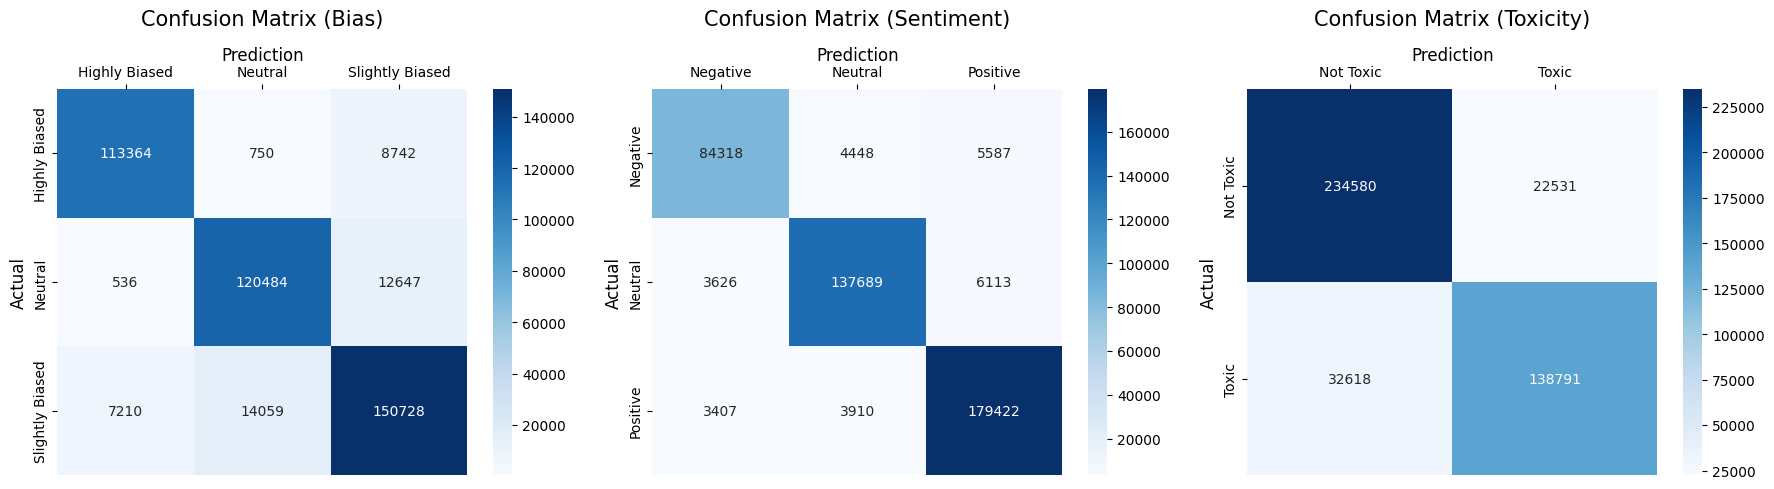

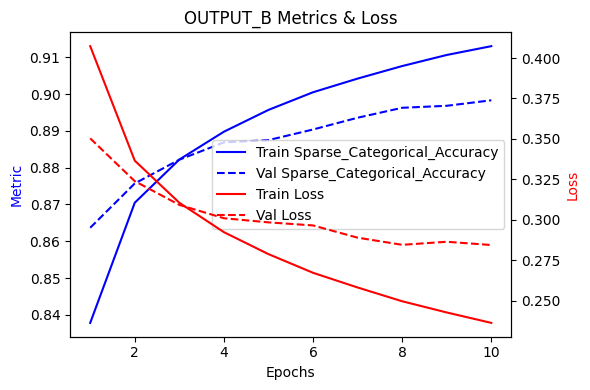

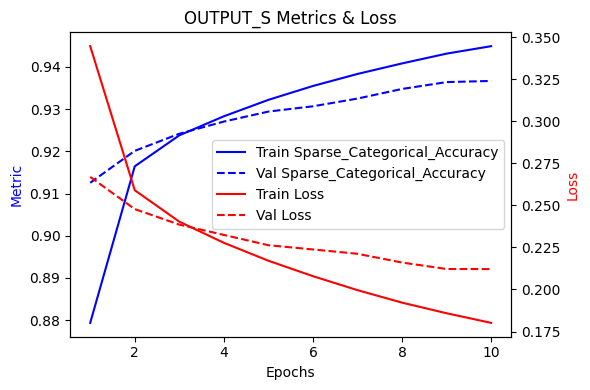

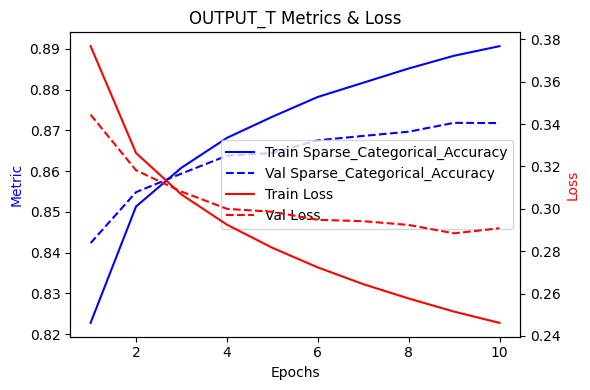


--------------------------------------------------------------------------



In [10]:
y_pred_probs = model.predict(X_test, batch_size=128)

y_pred_bias = np.argmax(y_pred_probs[0], axis=1)
y_pred_sentiment = np.argmax(y_pred_probs[1], axis=1)
y_pred_toxic = np.argmax(y_pred_probs[2], axis=1)

bias_labels = ['Highly Biased', 'Neutral', 'Slightly Biased']
sentiment_labels = ['Negative', 'Neutral', 'Positive']
toxicity_labels = ['Not Toxic', 'Toxic']

print("====================== Bias Task ======================")
print(f"Accuracy: {accuracy_score(y_test_bias, y_pred_bias):.4f}")
print(classification_report(y_test_bias, y_pred_bias, target_names=bias_labels))

print("\n==================== Sentiment Task ====================")
print(f"Accuracy: {accuracy_score(y_test_sentiment, y_pred_sentiment):.4f}")
print(classification_report(y_test_sentiment, y_pred_sentiment, target_names=sentiment_labels))

print("\n====================== Toxic Task ======================")
print(f"Accuracy: {accuracy_score(y_test_toxic, y_pred_toxic):.4f}")
print(classification_report(y_test_toxic, y_pred_toxic, target_names=toxicity_labels))

def plot_cm(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_xlabel('Prediction', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_test_bias, y_pred_bias, bias_labels, 'Confusion Matrix (Bias)', axes[0])
plot_cm(y_test_sentiment, y_pred_sentiment, sentiment_labels, 'Confusion Matrix (Sentiment)', axes[1])
plot_cm(y_test_toxic, y_pred_toxic, toxicity_labels, 'Confusion Matrix (Toxicity)', axes[2])

plt.tight_layout()
plt.show()

def plot_history_combined(history, outputs, metrics=None):
    if metrics is None:
        metrics = []
        for key in history.history.keys():
            for output in outputs:
                if key.startswith(output) and not key.endswith("loss"):
                    metric_name = key[len(output)+1:]  # remove output_
                    if metric_name not in metrics:
                        metrics.append(metric_name)
    
    epochs = range(1, len(history.history[f"{outputs[0]}_loss"]) + 1)

    for output in outputs:
        fig, ax1 = plt.subplots(figsize=(6, 4))

        ax2 = ax1.twinx()
        for metric in metrics:
            train_metric = history.history.get(f"{output}_{metric}")
            val_metric = history.history.get(f"val_{output}_{metric}")
            if train_metric and val_metric:
                ax1.plot(epochs, train_metric, "b-", label=f"Train {metric.title()}")
                ax1.plot(epochs, val_metric, "b--", label=f"Val {metric.title()}")

        train_loss = history.history.get(f"{output}_loss")
        val_loss = history.history.get(f"val_{output}_loss")
        if train_loss and val_loss:
            ax2.plot(epochs, train_loss, "r-", label="Train Loss")
            ax2.plot(epochs, val_loss, "r--", label="Val Loss")

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Metric", color="b")
        ax2.set_ylabel("Loss", color="r")
        ax1.set_title(f"{output.upper()} Metrics & Loss")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

        plt.tight_layout()
        plt.show()
    
outputs = ["output_b", "output_s", "output_t"]
plot_history_combined(history, outputs)

print("\n--------------------------------------------------------------------------\n")